In [3]:
import rasterio
from rasterio.warp import transform
import sys
!{sys.executable} -m pip install ipynb

import numpy as np
import torch
from torch import nn, distributions
from scipy.spatial.distance import cdist
from scipy.stats import norm
import matplotlib.pyplot as plt

torch.set_default_tensor_type(torch.FloatTensor)

In [4]:
vrt_path = "C:/Users/karlj/Desktop/nasadem_all/nasadem.vrt"     
#example query
points_lonlat = [(12.5683, 55.6761), (12.60, 55.70)]  # (lon, lat)

In [5]:
def query(vrt_path, points_lonlat):
    with rasterio.open(vrt_path) as src:
        # Reproject input lon/lat -> dataset CRS if needed
        if src.crs and src.crs.to_string() != "EPSG:4326":
            lons, lats = zip(*points_lonlat)
            xs, ys = transform("EPSG:4326", src.crs, lons, lats)
            pts = list(zip(xs, ys))
        else:
            pts = points_lonlat

        # Sample band 1
        vals = [v[0] for v in src.sample(pts)]
        return vals

In [6]:
def squared_exponential_kernel(x, y, lengthscale, variance):
    '''
    Function that computes the covariance matrix using a squared-exponential kernel
    '''
    # pair-wise distances, size: NxM
    sqdist = cdist(x.reshape((-1, 1)), y.reshape((-1, 1)), 'sqeuclidean')
    # compute the kernel
    cov_matrix = variance * np.exp(-0.5 * sqdist * (1/lengthscale**2))  # NxM
    return cov_matrix


def fit_predictive_GP(X, y, Xtest, lengthscale, kernel_variance, noise_variance):
    '''
    Function that fit the Gaussian Process. It returns the predictive mean function and
    the predictive covariance function. It follows step by step the algorithm on the lecture
    notes
    '''
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    K = squared_exponential_kernel(X, X, lengthscale, kernel_variance)
    L = np.linalg.cholesky(K + noise_variance * np.eye(len(X)))

    # compute the mean at our test points.
    Ks = squared_exponential_kernel(X, Xtest, lengthscale, kernel_variance)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))  #
    mu = Ks.T @ alpha

    v = np.linalg.solve(L, Ks)
    # compute the variance at our test points.
    Kss = squared_exponential_kernel(Xtest, Xtest, lengthscale, kernel_variance)
    covariance = Kss - (v.T @ v)
    
    return mu, covariance


# I am using PyTorch to define the optimization function, it can be done in different other ways.
# It is not the best way to implement it, I suppose
def optimize_GP_hyperparams(Xtrain, ytrain, optimization_steps, learning_rate, mean_prior, prior_std):
    '''
    Methods that run the otpimization of the hyperparams of our GP. We will use
    Gradient Descent because it takes to much time to run grid search at each step
    of bayesian optimization. We use a different definition of the kernel to make the
    optimization more stable

    :param X: training set points
    :param y: training targets
    :return: values for lengthscale, output_var, noise_var that maximize the log-likelihood
    '''
    
    # we are re-defining the kernel because we need it in PyTorch
    def squared_exponential_kernel_torch(x, y, _lambda, variance):
        x = x.squeeze(1).expand(x.size(0), y.size(0))
        y = y.squeeze(0).expand(x.size(0), y.size(0))
        sqdist = torch.pow(x - y, 2)
        k = variance * torch.exp(-0.5 * sqdist * (1/_lambda**2))  # NxM
        return k

    X = np.array(Xtrain).reshape(-1,1)
    y = np.array(ytrain).reshape(-1,1)
    N = len(X)

    # tranform our training set in Tensor
    Xtrain_tensor = torch.from_numpy(X).float()
    ytrain_tensor = torch.from_numpy(y ).float()
    # we should define our hyperparameters as torch parameters where we keep track of
    # the operations to get hte gradients from them
    _lambda = nn.Parameter(torch.tensor(1.), requires_grad=True)
    output_variance = nn.Parameter(torch.tensor(1.), requires_grad=True)
    noise_variance = nn.Parameter(torch.tensor(.5), requires_grad=True)

    # we use Adam as optimizer
    optim = torch.optim.Adam([_lambda, output_variance, noise_variance], lr=learning_rate)

    # optimization loop using the log-likelihood that involves the cholesky decomposition 
    nlls = []
    lambdas = []
    output_variances = []
    noise_variances = []
    iterations = optimization_steps
    for i in range(iterations):
        assert noise_variance >= 0, f"ouch! {i, noise_variance}"
        optim.zero_grad()
        K = squared_exponential_kernel_torch(Xtrain_tensor, Xtrain_tensor, _lambda,
                                                output_variance) + noise_variance * torch.eye(N)
        
        L = torch.linalg.cholesky(K)
        _alpha_temp = torch.linalg.solve_triangular(L, ytrain_tensor,upper=False)
        _alpha = torch.linalg.solve_triangular(L.t(),_alpha_temp,upper=True)
        nll = N / 2 * torch.log(torch.tensor(2 * np.pi)) + 0.5 * torch.matmul(ytrain_tensor.transpose(0, 1),
                                                                              _alpha) + torch.sum(torch.log(torch.diag(L)))

        # we have to add the log-likelihood of the prior
        norm = distributions.Normal(loc=mean_prior, scale=prior_std)
        prior_negloglike =  torch.log(_lambda) - norm.log_prob(_lambda)

        nll += 0.9 * prior_negloglike
        nll.backward()

        nlls.append(nll.item())
        lambdas.append(_lambda.item())
        output_variances.append(output_variance.item())
        noise_variances.append(noise_variance.item())
        optim.step()

        # projected in the constraints (lengthscale and output variance should be positive)
        for p in [_lambda, output_variance]:
            p.data.clamp_(min=0.0000001)

        noise_variance.data.clamp_(min=1e-5, max= 0.05)

        
    return _lambda.item(), output_variance.item(), noise_variance.item()

In [7]:
## safety check: we try to run the code in the dataset of last lecture and see if it works
from scipy.io import loadmat

## We load the data and use only some of them.
## We subsample the data, which gives us N pairs of (x, y)
M = 1000
data = loadmat('weather_dataset.mat')
# sampling part 
Xtrain = np.arange(0, M, 20)
ytrain = data['TMPMAX'][Xtrain]
N = len(ytrain)
Xtrain = Xtrain.reshape(-1,1)

# print dataset information
print('Xtrain shape', Xtrain.shape)
print('ytrain shape', ytrain.shape)

# also in this case we standardize the data to have zero mean and unit variance
Xtrain = (Xtrain - np.mean(Xtrain)) / np.std(Xtrain)
ytrain = (ytrain - np.mean(ytrain)) / np.std(ytrain)

# and plot it
plt.plot(Xtrain, ytrain, 'o', color='black')
plt.ylabel('Normalized level of precipitations')
plt.xlabel('Time')
plt.show()

# we shall also define the test set, that is the range of XTest points we want to 
# use to compute the mean and the variance
Xtest = np.linspace(-2, 2, M).reshape(-1,1)

## we have to define the mena and variance of the log-normal distribution for the lengthscale prior 
prior_mean = 0.
prior_std = 3.

lengthscale, output_var, noise_var = optimize_GP_hyperparams(Xtrain, ytrain, 500, 5e-3, prior_mean, prior_std)
print('Optimized parameters:', lengthscale, output_var, noise_var)

# we can fit the GP that use the hyperparameters found above
mu, covariance = fit_predictive_GP(Xtrain, ytrain, Xtest, lengthscale, output_var, noise_var)
std = np.sqrt(np.diag(covariance))
plt.plot(Xtrain, ytrain, 'ro', label='Training points')
plt.gca().fill_between(Xtest.flat, mu.reshape(-1) - 2 * std, mu.reshape(-1) + 2 * std,  color='lightblue', alpha=0.5, label=r"$2\sigma$")
plt.plot(Xtest, mu, 'blue', label=r"$\mu$")
plt.legend()
plt.show() 


FileNotFoundError: [Errno 2] No such file or directory: 'weather_dataset.mat'

In [8]:
# we want to define the function over all the points in the
# range of interest, defined as X
def probability_of_improvement(current_best, mean, std, xi):
    '''
    Thus function implements the probability of improvement acquisition function.
    It implements
        PI(x) = P(f(x) >= f(x^+))
            since we consider f(x^+) = mu^+ + epxis we have
              = Phi ( (mu - mu^+ - xi) / sigma )
    :param current_best: this is the current max of the unknown function: mu^+
    :param mean: this is the mean function from the GP over the considered set of points
    :param std: this is the std function from the GP over the considered set of points
    :param xi: small value added to avoid corner case
    :return: the value of this acquisition function for all the points
    '''
    # since std coan be 0, to avoid an error, we add a small value in the denominator (like +1e-9)
    PI =  norm.cdf((mean - current_best - xi) / (std + 1e-9))
    return PI 


def expected_improvement(current_best, mean, std, xi):
    '''
    It implements the following function:

            | (mu - mu^+ - xi) Phi(Z) + sigma phi(Z) if sigma > 0
    EI(x) = |
            | 0                                       if sigma = 0

            where Phi is the CDF and phi the PDF of the normal distribution
            and
            Z = (mu - mu^+ - xi) / sigma

    :param current_best: this is the current max of the unknown function: mu^+
    :param mean: this is the mean function from the GP over the considered set of points
    :param std: this is the std function from the GP over the considered set of points
    :param xi: small value added to avoid corner case
    :return: the value of this acquisition function for all the points
    '''

    # start by computing the Z as we did in the probability of improvement function
    # to avoid division by 0, add a small term eg. np.spacing(1e6) to the denominator
    Z = (mean - current_best - xi) / (std + 1e-9) # or Z = (mean - current_best - eps) / (std + np.spacing(1e6))
    # now we have to compute the output only for the terms that have their std > 0
    EI = (mean - current_best - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    EI[std == 0] = 0
    
    return EI


def GP_UCB(mean, std, t, dim = 1.0, v = 1.0, delta = .1):
    '''
    Implementation of the Gaussian Process - Upper Confident Bound:
        GP-UBC(x) = mu + sqrt(v * beta) * sigma

    where we are usinv v = 1 and beta = 2 log( t^(d/2 + 2) pi^2 / 3 delta)
    as proved in Srinivas et al, 2010, to have 0 regret.

    :param mean: this is the mean function from the GP over the considered set of points
    :param std: this is the std function from the GP over the considered set of points
    :param t: iteration number
    :param dim: dimension of the input space
    :param v: hyperparameter that weights the beta for the exploration-exploitation trade-off. If v = 1 and another
              condition, it is proved we have 0 regret
    :param delta: hyperparameter used in the computation of beta
    :return: the value of this acquisition function for all the points
    '''
    beta =  2 * np.log((t**( (dim/2) + 2) * np.pi**2 / (3 * delta)) + 1e-9)
    UCB = mean + np.sqrt(v * beta) * std
    
    return UCB



def GP_UCB_approx(mean, std, t, eps):
    '''
    Implementation of the Gaussian Process - Upper Confident Bound in a easy approximate way:
        GP-UBC(x) = mu + eps * log(t) * sigma

    we use the fact that beta ~ log(t)^2, so we have sqrt(v * log(t)^2) = log(t)*sqrt(v) ~ eps * log(t)

    :param mean: this is the mean function from the GP over the considered set of points
    :param std: this is the std function from the GP over the considered set of points
    :param t: iteration number
    :param eps: trade-off constant
    :return: the value of this acquisition function for all the points
    '''
    UCB = mean + eps * np.log(t) * std
    return UCB 


## the following one was not in the original exercise, but in the plot part we forgot to delete the code
## related to this. Therefore I am posting here the original UCB
def GP_UCB_original(mean, std, kappa):
    '''
    Implementation of the Gaussian Process - Upper Confident Bound in a easy approximate way:
        GP-UBC(x) = mu + kappa * sigma


    :param mean: this is the mean function from the GP over the considered set of points
    :param std: this is the std function from the GP over the considered set of points
    :param t: iteration number
    :param kappa: trade-off constant
    :return: the value of this acquisition function for all the points
    '''

    return mean + kappa * std

0.13866150379180908 3.88468861579895 0.05000000074505806


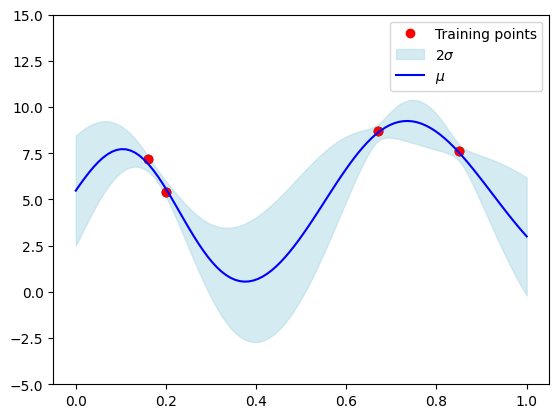

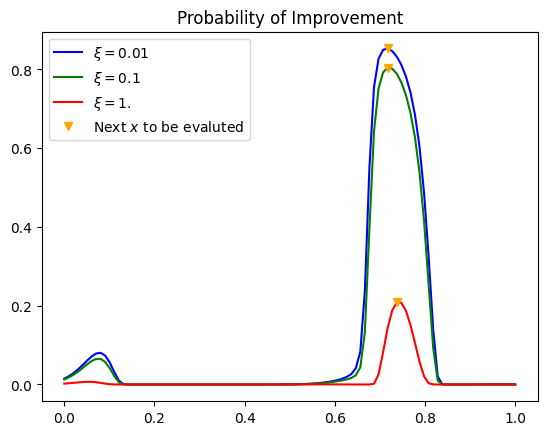

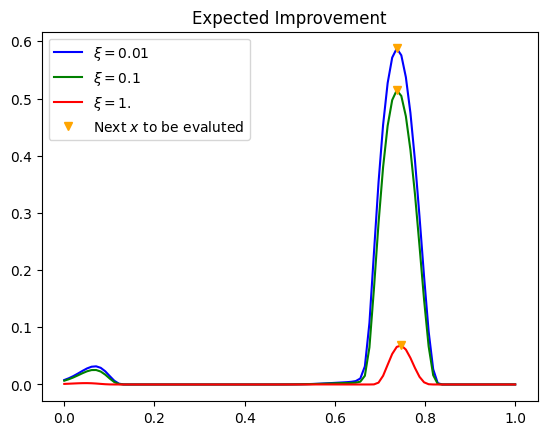

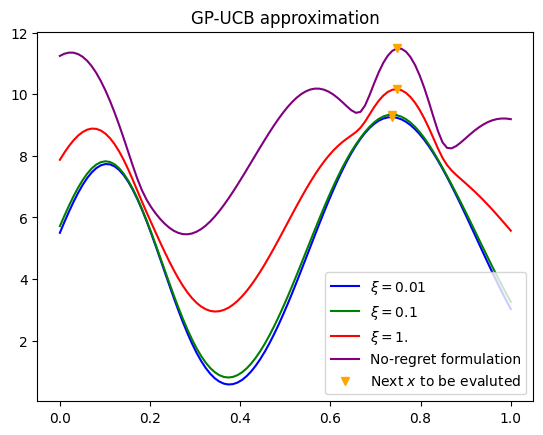

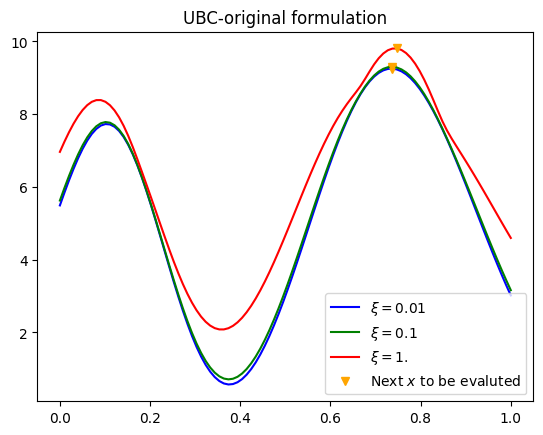

In [9]:
### testing example
# create toy dataset

# space of interest
xs = np.linspace(0,1,100)

X_samples = [0.16, 0.2, 0.67, 0.85]
#y_samples = [6.2, 6.5, 7.9, 9] # if you divide those by 10 it does not work!
y_samples = [7.2, 5.4, 8.7, 7.6]
## plot the dataset
plt.plot(X_samples, y_samples, 'o', color='black')
plt.xlim(0.,1.)
plt.ylim(-5.,15)

## prior for the lengthscale
prior_mean = 0
prior_std = 5

lengthscale, output_var, noise_var = optimize_GP_hyperparams(X_samples, y_samples, 1000, 5e-3, prior_mean, prior_std)
print(lengthscale, output_var, noise_var)

# we can fit the GP that use the hyperparameters found above
mu, covariance = fit_predictive_GP(X_samples, y_samples, xs, lengthscale, output_var, noise_var)
std = np.sqrt(np.diag(covariance))
plt.plot(X_samples, y_samples, 'ro', label='Training points')
plt.gca().fill_between(xs.flat, mu.reshape(-1) - 2 * std, mu.reshape(-1) + 2 * std,  color='lightblue', alpha=0.5, label=r"$2\sigma$")
plt.plot(xs, mu, 'blue', label=r"$\mu$")
plt.xlim([-0.05,1.05])
plt.legend()
plt.show() 


current_best = np.max(y_samples)
t = len(X_samples) + 1 
## compute the acquisition functions
## probability of improvement
acquisition_values1 = probability_of_improvement(current_best,  mu, std, 0.01)
next_x1 = np.argmax(acquisition_values1)
acquisition_values2 = probability_of_improvement(current_best,  mu, std, 0.1)
next_x2 = np.argmax(acquisition_values2)
acquisition_values3 = probability_of_improvement(current_best,  mu, std, 1)
next_x3 = np.argmax(acquisition_values3)

# plot them
plt.plot(xs, acquisition_values1, '-', color='blue', label =r'$\xi = 0.01$')
plt.plot(xs[next_x1], acquisition_values1[next_x1], 'v', color='orange')
plt.plot(xs, acquisition_values2, '-', color='green', label =r'$\xi = 0.1$')
plt.plot(xs[next_x2], acquisition_values2[next_x2], 'v', color='orange')
plt.plot(xs, acquisition_values3, '-', color='red', label =r'$\xi = 1.$')
plt.plot(xs[next_x3], acquisition_values3[next_x3], 'v', color='orange', label='Next $x$ to be evaluted')
plt.title('Probability of Improvement')
plt.legend()
plt.show()


## expected_improvement
acquisition_values1 = expected_improvement(current_best,  mu, std, 0.01)
next_x1 = np.argmax(acquisition_values1)
acquisition_values2 = expected_improvement(current_best,  mu, std, 0.1)
next_x2 = np.argmax(acquisition_values2)
acquisition_values3 = expected_improvement(current_best,  mu, std, 1)
next_x3 = np.argmax(acquisition_values3)

# plot them
plt.plot(xs, acquisition_values1, '-', color='blue', label =r'$\xi = 0.01$')
plt.plot(xs[next_x1], acquisition_values1[next_x1], 'v', color='orange')
plt.plot(xs, acquisition_values2, '-', color='green', label =r'$\xi = 0.1$')
plt.plot(xs[next_x2], acquisition_values2[next_x2], 'v', color='orange')
plt.plot(xs, acquisition_values3, '-', color='red', label =r'$\xi = 1.$')
plt.plot(xs[next_x3], acquisition_values3[next_x3], 'v', color='orange', label='Next $x$ to be evaluted')
plt.title('Expected Improvement')
plt.legend()
plt.show()


## GP-UCB approximate and no-regret
acquisition_values1 = GP_UCB_approx(mu, std, t, 0.01)
next_x1 = np.argmax(acquisition_values1)
acquisition_values2 = GP_UCB_approx(mu, std, t, 0.1)
next_x2 = np.argmax(acquisition_values2)
acquisition_values3 = GP_UCB_approx(mu, std, t, 1)
next_x3 = np.argmax(acquisition_values3)

acquisition_values_no_regret = GP_UCB(mu, std, t)
next_x_no_regret = np.argmax(acquisition_values_no_regret)

# plot them
plt.plot(xs, acquisition_values1, '-', color='blue', label =r'$\xi = 0.01$')
plt.plot(xs[next_x1], acquisition_values1[next_x1], 'v', color='orange')
plt.plot(xs, acquisition_values2, '-', color='green', label =r'$\xi = 0.1$')
plt.plot(xs[next_x2], acquisition_values2[next_x2], 'v', color='orange')
plt.plot(xs, acquisition_values3, '-', color='red', label =r'$\xi = 1.$')
plt.plot(xs[next_x3], acquisition_values3[next_x3], 'v', color='orange')
plt.plot(xs, acquisition_values_no_regret, '-', color='purple', label =r'No-regret formulation')
plt.plot(xs[next_x_no_regret], acquisition_values_no_regret[next_x_no_regret], 'v', color='orange', label='Next $x$ to be evaluted')
plt.title('GP-UCB approximation')
plt.legend()
plt.show()

## GP-UCB original formulation
acquisition_values1 = GP_UCB_original( mu, std, 0.01)
next_x1 = np.argmax(acquisition_values1)
acquisition_values2 = GP_UCB_original(  mu, std, 0.1)
next_x2 = np.argmax(acquisition_values2)
acquisition_values3 = GP_UCB_original(  mu, std, 1)
next_x3 = np.argmax(acquisition_values3)

# plot them
plt.plot(xs, acquisition_values1, '-', color='blue', label =r'$\xi = 0.01$')
plt.plot(xs[next_x1], acquisition_values1[next_x1], 'v', color='orange')
plt.plot(xs, acquisition_values2, '-', color='green', label =r'$\xi = 0.1$')
plt.plot(xs[next_x2], acquisition_values2[next_x2], 'v', color='orange')
plt.plot(xs, acquisition_values3, '-', color='red', label =r'$\xi = 1.$')
plt.plot(xs[next_x3], acquisition_values3[next_x3], 'v', color='orange', label='Next $x$ to be evaluted')
plt.title('UBC-original formulation')
plt.legend()
plt.show()

In [13]:
np.random.seed(32)
# points that we are considering
X = np.linspace(0,2,200)

# prior over the lengthscale
prior_mean = 0 
prior_std = 5

# array for the points x' and repective f(x') that we sample using the acquisition function
X_sample = []
y_sample = []

# number of iterations
T = 15

# number of initial random samples
init_samples = 10

# trade-off hyperparams
eps = 0.5

long = (9,17) 
lat = (46, 49)

# get some random samples
# for _ in range(init_samples):
#     # sample a point at random
#     xt = [(long[i], lat[j]) for i in range(2) for j in range(2)]
#     # evaluate the point
#     for val in xt:
#         X_sample.append(val)
#     # we query the function
#     y_sample.append(query(vrt_path, xt))

X_sample = [(long[i], lat[j]) for i in range(2) for j in range(2)]      # creating the initial samples from outermost points
y_sample = [query(vrt_path, [x]) for x in X_sample]
    
# bayesian optimization loop
# compute the current best 
current_best = np.max(y_sample)

# loop
acquisition = 'improvement'

for t in range(len(X_sample),len(X_sample) + T):
    ## we should optimize the GP hyperparameters before fitting the final GP and computing the acquisition
    ## functions
    lengthscale, output_variance, noise_variance = optimize_GP_hyperparams(X_sample, y_sample, 500, 5e-3, prior_mean, prior_std)
    print(lengthscale, output_variance, noise_variance)
    # we have to fit the GP using the X_sample, Y_sample and our training point
    mu, covariance = fit_predictive_GP(X_sample, y_sample, X, lengthscale, output_variance, noise_variance)
    # get the standard deviation
    std = np.sqrt(np.diag(covariance))

    ## calculate acquisition values for your acquisition function of choice
    ## now we have to use the acquisition function
    if acquisition == 'probability':
        acquisition_values = probability_of_improvement(current_best,  mu, std, eps)
        # print(acquisition_values)
    elif acquisition == 'improvement':
        acquisition_values = expected_improvement(current_best,  mu, std, eps)
    elif acquisition == 'GP-UCB-approx':
        acquisition_values = GP_UCB_approx(mu, std, t, eps)
    elif acquisition == 'GP-UCB-orig':
        acquisition_values = GP_UCB_original(mu, std, eps)
    else:
        assert acquisition == 'GP-UCB', "You have insert a wrong acquisition function"
        acquisition_values = GP_UCB(mu, std, t)
    
    # we have to find the xt that maximizes this acquisition function
    xt = X[np.argmax(acquisition_values)]


    ## now we should create the plots
    if t > 0:
        plt.figure(figsize=(12, 8))
        fig, axs = plt.subplots(2)
        fig.suptitle(f't = {t}')
        axs[0].fill_between(X.flat, mu - std, mu + std,  color='lightblue', alpha=0.5, label = r"$\sigma$")
        # axs[0].fill_between(X.flat, mu - noise_, mu + noise_, color='red', alpha=0.4, label=r"predictive")
        axs[0].plot(X, mu, 'b-', label=r'$\mu$')

        if len(X_sample) > 0:
            axs[0].plot(X_sample, y_sample, 'bo', label='Sampled points')
        axs[0].plot(xt, query(vrt_path, xt), 'yo', label='Next sampled point')
        axs[0].legend()

        #plot acquisition
        axs[1].plot(X, acquisition_values, '-', color = 'green', label = 'acquisition function')
        axs[1].axvline(xt, color = 'red', linestyle = '--', label='Position of the next x evaluated')
        axs[1].legend()
        plt.show()

    # we compute the value of xt and we add xt and f(xt) in X_samples and y_samples
    X_sample.append(xt)
    # we append a noisy observation (should we?)
    y_sample.append(query(vrt_path, xt))

    # update current best
    current_best = np.max(y_sample)
    
    
print('\n Candidates for the maximum of the function are:')
print("X's: ", X_sample)
print("Respective y's: ", y_sample)
print('--------------')
print('The max of the function found by the algorithm is: ', np.max(y_sample))

RuntimeError: linalg.solve_triangular: Incompatible shapes of A and B for the equation AX = B (8x8 and 4x1)